In [29]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')

### Dataset Overview

Let's take a look at the first few rows of the dataset to understand its structure and content.

In [30]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### Data Information

Now, let's check the data types and non-null values for each column to identify any immediate issues or areas for preprocessing.

In [31]:
# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


### Data Preprocessing

First, we'll convert the 'Date' column to a datetime object. This is a crucial step for any time series analysis, as it allows us to easily extract temporal features and perform time-based operations.

Then, we'll extract `Year`, `Month`, and `Quarter` from the `Date` column as new features. These features can help capture seasonal patterns and trends in the delivery data.

In [32]:

df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Display the DataFrame with new features and check data types again
display(df.head())
df.info()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,1
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int32         
 1   Month                 2640 non-null   int32         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[ns]
 13  Quarter           

### Check for Missing Values

Next, let's check for any missing values in the dataset. Handling missing data is an important part of preprocessing to ensure the quality and reliability of our analysis and models.

In [33]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [34]:
# Check for missing values again (should now work)
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


### Exploratory Data Analysis (EDA) - Continued

Now that the data is correctly preprocessed, let's proceed with the detailed Exploratory Data Analysis. We'll start by examining descriptive statistics and then visualize key trends.

In [35]:
# Descriptive statistics for 'Estimated_Deliveries'
print('Descriptive Statistics for Estimated_Deliveries:')
print(df['Estimated_Deliveries'].describe())

Descriptive Statistics for Estimated_Deliveries:
count     2640.000000
mean      9922.199621
std       3935.950093
min         48.000000
25%       7292.000000
50%       9857.000000
75%      12510.250000
max      25704.000000
Name: Estimated_Deliveries, dtype: float64


### Visualize Estimated Deliveries Over Time

Let's plot the 'Estimated_Deliveries' over time to observe trends and seasonality.

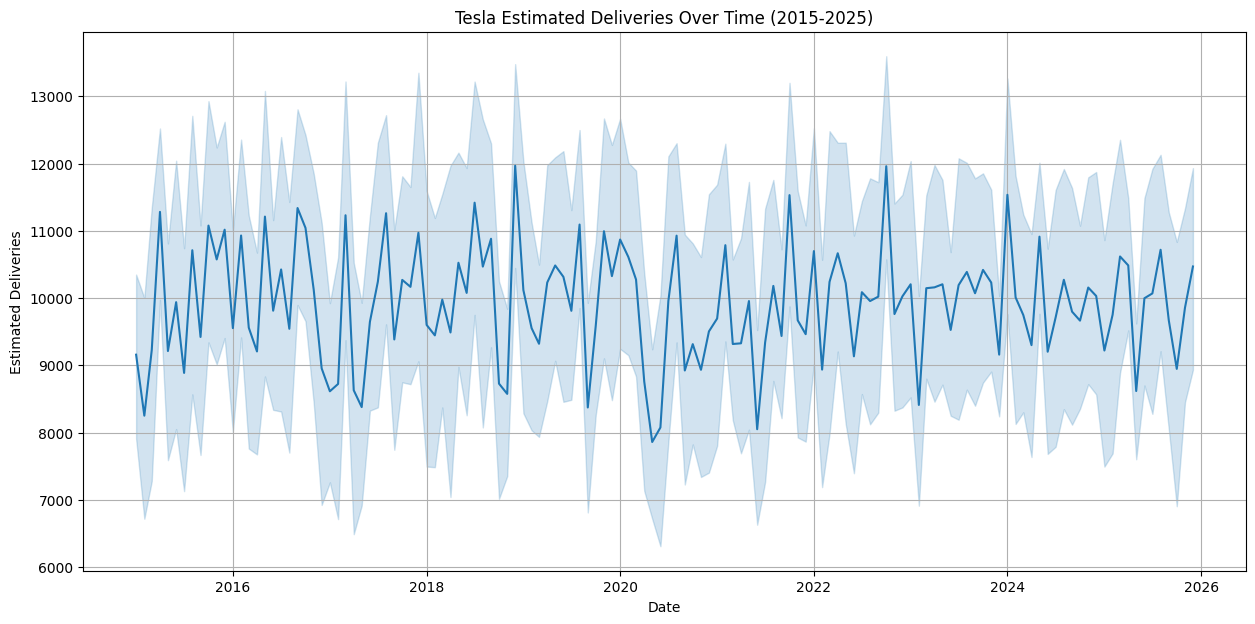

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 7))
sns.lineplot(x='Date', y='Estimated_Deliveries', data=df)
plt.title('Tesla Estimated Deliveries Over Time (2015-2025)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.show()

### Distribution of Estimated Deliveries

Now, let's visualize the distribution of 'Estimated_Deliveries' to identify its spread and potential outliers.

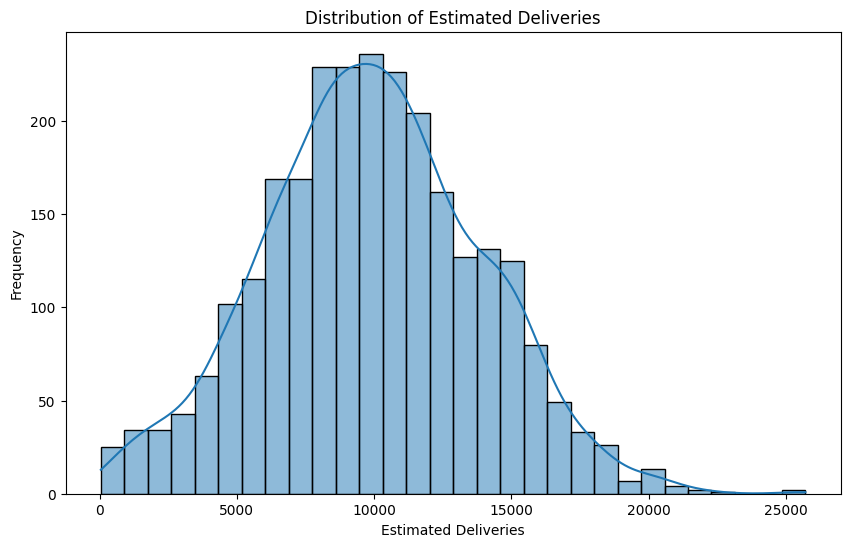

In [37]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')
plt.show()

### Feature Engineering

In this section, we will create new features that can help our models better understand the patterns in the data. For time series data, common feature engineering techniques include creating lag features, rolling statistics, and cyclical features from temporal components. We will also encode categorical variables.

In [38]:
# Sort data by Date, which is essential for time series feature engineering
df = df.sort_values(by='Date').reset_index(drop=True)

# Display the sorted DataFrame head
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1


#### Lag Features

Lag features are past values of a time series. They can be very effective in predicting future values as many time series exhibit autocorrelation (correlation with their own past values). We will create lags for 'Estimated_Deliveries'.

In [39]:
# Create lag features for 'Estimated_Deliveries'
for lag in range(1, 4): # Create lag features for 1, 2, and 3 months prior
    df[f'Deliveries_Lag_{lag}'] = df.groupby(['Region', 'Model'])[f'Estimated_Deliveries'].transform(lambda x: x.shift(lag))

# Display the DataFrame with new lag features
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Deliveries_Lag_1,Deliveries_Lag_2,Deliveries_Lag_3
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,NaN,NaN,NaN
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,NaN,NaN,NaN
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,NaN,NaN,NaN
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,NaN,NaN,NaN
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,NaN,NaN,NaN


#### Rolling Window Features

Rolling window features, such as moving averages or moving standard deviations, can capture trends and volatility over a specific period. These are particularly useful for smoothing out short-term fluctuations and highlighting longer-term trends.

In [40]:
# Create rolling window features (e.g., 3-month rolling mean and std)
for window in [3, 6]:
    df[f'Deliveries_Rolling_Mean_{window}'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(window=window).mean())
    df[f'Deliveries_Rolling_Std_{window}'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].transform(lambda x: x.rolling(window=window).std())

# Display the DataFrame with new rolling features
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Charging_Stations,Date,Quarter,Deliveries_Lag_1,Deliveries_Lag_2,Deliveries_Lag_3,Deliveries_Rolling_Mean_3,Deliveries_Rolling_Std_3,Deliveries_Rolling_Mean_6,Deliveries_Rolling_Std_6
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,...,4390,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,...,8925,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,...,3923,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,...,9170,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,...,12626,2015-01-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Cyclical Features

Time-based features like 'Month' and 'Quarter' often have a cyclical nature. Encoding them using sine and cosine transformations can help the model capture this periodicity, as it maintains the relationship between the start and end of the cycle (e.g., December and January are close).

In [41]:
import numpy as np

# Create cyclical features for Month and Quarter
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Quarter_sin'] = np.sin(2 * np.pi * df['Quarter'] / 4)
df['Quarter_cos'] = np.cos(2 * np.pi * df['Quarter'] / 4)

# Display the DataFrame with new cyclical features
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Deliveries_Lag_2,Deliveries_Lag_3,Deliveries_Rolling_Mean_3,Deliveries_Rolling_Std_3,Deliveries_Rolling_Mean_6,Deliveries_Rolling_Std_6,Month_sin,Month_cos,Quarter_sin,Quarter_cos
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,1.0,6.123234e-17
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,1.0,6.123234e-17
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,1.0,6.123234e-17
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,1.0,6.123234e-17
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,...,NaN,NaN,NaN,NaN,NaN,NaN,0.5,0.866025,1.0,6.123234e-17


#### One-Hot Encoding for Categorical Features

Categorical features like 'Region', 'Model', and 'Source_Type' need to be converted into a numerical format for most machine learning models. One-hot encoding creates binary columns for each category, preventing the model from assuming an ordinal relationship between categories.

In [42]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

# Display the DataFrame with one-hot encoded features
display(df.head())
df.info()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Quarter_cos,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,...,6.123234e-17,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,...,6.123234e-17,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,...,6.123234e-17,False,True,False,False,False,False,False,True,False
3,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,...,6.123234e-17,False,False,True,False,False,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,...,6.123234e-17,False,False,False,True,False,False,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Year                              2640 non-null   int32         
 1   Month                             2640 non-null   int32         
 2   Estimated_Deliveries              2640 non-null   int64         
 3   Production_Units                  2640 non-null   int64         
 4   Avg_Price_USD                     2640 non-null   float64       
 5   Battery_Capacity_kWh              2640 non-null   int64         
 6   Range_km                          2640 non-null   int64         
 7   CO2_Saved_tons                    2640 non-null   float64       
 8   Charging_Stations                 2640 non-null   int64         
 9   Date                              2640 non-null   datetime64[ns]
 10  Quarter                           2640 non-null 

#### Handle Missing Values Introduced by Feature Engineering

Lag and rolling window features can introduce NaN values at the beginning of the time series. We need to handle these missing values, typically by dropping them or imputing them. For simplicity, we will drop rows with NaN values, assuming we have enough data.

In [43]:
# Drop rows with NaN values introduced by lag and rolling features
df.dropna(inplace=True)

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

# Display the cleaned DataFrame and check for any remaining missing values
display(df.head())
print('Missing values after dropping NaNs:')
print(df.isnull().sum().sum())

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Quarter_cos,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,6,8199,8753,59041.16,120,717,881.80,10274,2015-06-01,...,-1.0,False,False,True,False,True,False,False,False,False
1,2015,6,15474,16287,91294.24,82,467,1083.95,8249,2015-06-01,...,-1.0,True,False,False,False,True,False,False,False,True
2,2015,6,8922,9609,104855.71,75,427,571.45,10465,2015-06-01,...,-1.0,True,False,False,True,False,False,False,False,True
3,2015,6,6828,7039,75498.89,100,575,588.91,11284,2015-06-01,...,-1.0,False,False,False,False,False,False,True,True,False
4,2015,6,7878,8087,56209.18,75,417,492.77,8529,2015-06-01,...,-1.0,False,False,False,False,False,True,False,False,True


Missing values after dropping NaNs:
0


### Regression Modeling

Now, we'll prepare the data for regression modeling. This involves selecting the features (X) and the target variable (y), splitting the data into training and testing sets, and then training a suitable regression model.

### Feature Correlation Heatmap

Let's visualize the correlation between all features and the target variable. A heatmap can quickly show us which features are highly correlated with each other and with the `Estimated_Deliveries`.

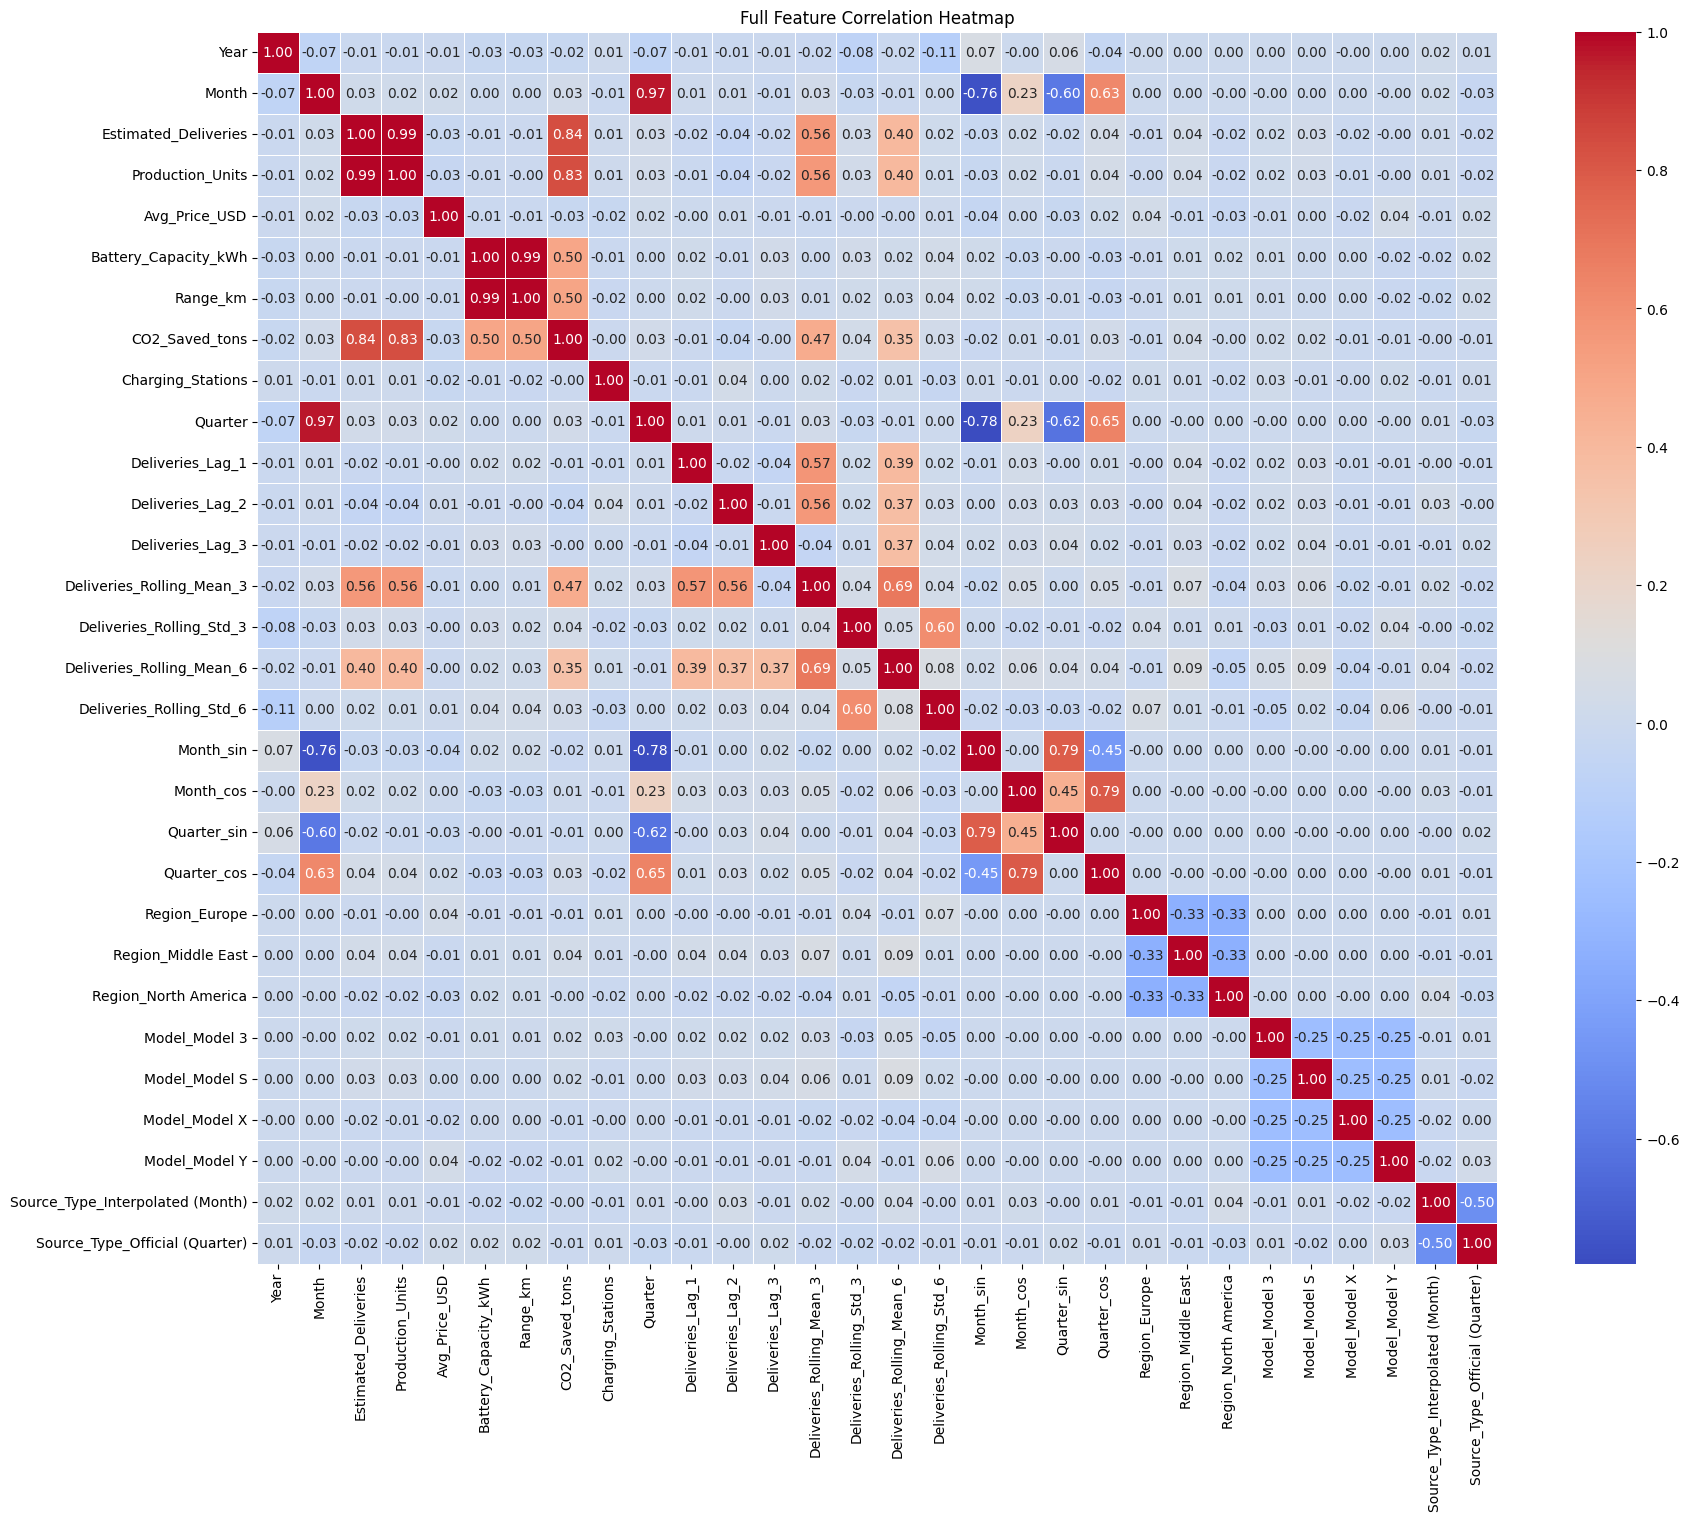

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for all numerical columns
# Include 'Estimated_Deliveries' to see its correlation with features
correlation_matrix = df.drop(columns=['Date']).corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Full Feature Correlation Heatmap')
plt.show()

In [44]:
# Define features (X) and target (y)

# Also drop 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations'
# for simplicity as the primary focus is time series forecasting of deliveries.
# These can be included in future iterations if they are considered features for prediction.

features = df.drop(columns=[
    'Date',
    'Estimated_Deliveries',
    'Year',
    'Month',
    'Quarter',
    'Production_Units', # Production Units might be too direct a predictor or cause leakage if not handled carefully
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
])
target = df['Estimated_Deliveries']

X = features
y = target

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")
print("Features selected:")
print(X.columns.tolist())

Shape of features (X): (2540, 20)
Shape of target (y): (2540,)
Features selected:
['Deliveries_Lag_1', 'Deliveries_Lag_2', 'Deliveries_Lag_3', 'Deliveries_Rolling_Mean_3', 'Deliveries_Rolling_Std_3', 'Deliveries_Rolling_Mean_6', 'Deliveries_Rolling_Std_6', 'Month_sin', 'Month_cos', 'Quarter_sin', 'Quarter_cos', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


### Data Splitting for Time Series

For time series data, it's crucial to split the data chronologically to prevent data leakage. We'll use an 80/20 split based on the date, where the earlier 80% of the data is used for training and the later 20% for testing.

In [45]:
# Sort the DataFrame by Date again to ensure chronological order for splitting
df_sorted = df.sort_values('Date')

# Determine the split point (e.g., 80% for training)
split_point = int(len(df_sorted) * 0.8)

# Split data into training and testing sets
X_train = df_sorted.iloc[:split_point][X.columns]
X_test = df_sorted.iloc[split_point:][X.columns]
y_train = df_sorted['Estimated_Deliveries'].iloc[:split_point]
y_test = df_sorted['Estimated_Deliveries'].iloc[split_point:]

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 2032 samples
Test set size: 508 samples


### Model Training: RandomForestRegressor

We will use a `RandomForestRegressor` for our regression task. Random Forests are ensemble learning methods that work well with various types of data and are robust to outliers and multicollinearity. They are also capable of capturing non-linear relationships.

In [46]:
from sklearn.ensemble import RandomForestRegressor


model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training RandomForestRegressor...")
model.fit(X_train, y_train)
print("Training complete.")

Training RandomForestRegressor...
Training complete.


### Model Evaluation

Now, let's evaluate the performance of our trained `RandomForestRegressor` model on the test set. We'll use common regression metrics like Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared to assess its accuracy.

Mean Absolute Error (MAE): 559.44
Mean Squared Error (MSE): 542018.61
Root Mean Squared Error (RMSE): 736.22
R-squared (R2): 0.96


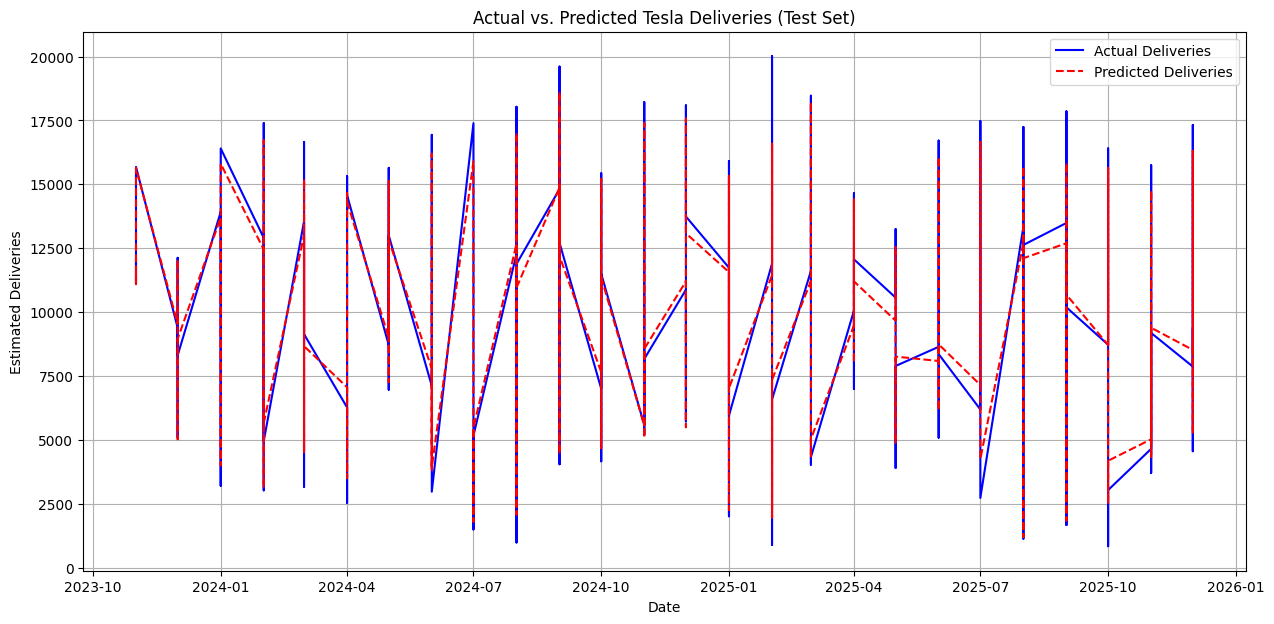

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actuals
plt.figure(figsize=(15, 7))
plt.plot(df_sorted['Date'].iloc[split_point:], y_test, label='Actual Deliveries', color='blue')
plt.plot(df_sorted['Date'].iloc[split_point:], y_pred, label='Predicted Deliveries', color='red', linestyle='--')
plt.title('Actual vs. Predicted Tesla Deliveries (Test Set)')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

### Hyperparameter Tuning

To further optimize the performance of our `RandomForestRegressor`, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating each combination to determine which one performs best.

In [48]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)


grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

print("Starting GridSearchCV for hyperparameter tuning...")

grid_search.fit(X_train, y_train)
print("GridSearchCV complete.")

Starting GridSearchCV for hyperparameter tuning...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
GridSearchCV complete.


### Best Model from Hyperparameter Tuning

After `GridSearchCV` completes, we can retrieve the best parameters found and the best performing model. This optimized model should ideally provide better predictions than the initial model.

Best parameters found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Tuned Model Performance:
Mean Absolute Error (MAE): 560.70
Mean Squared Error (MSE): 534787.07
Root Mean Squared Error (RMSE): 731.29
R-squared (R2): 0.96

Initial Model MAE: 559.44, Tuned Model MAE: 560.70
Initial Model R2: 0.96, Tuned Model R2: 0.96


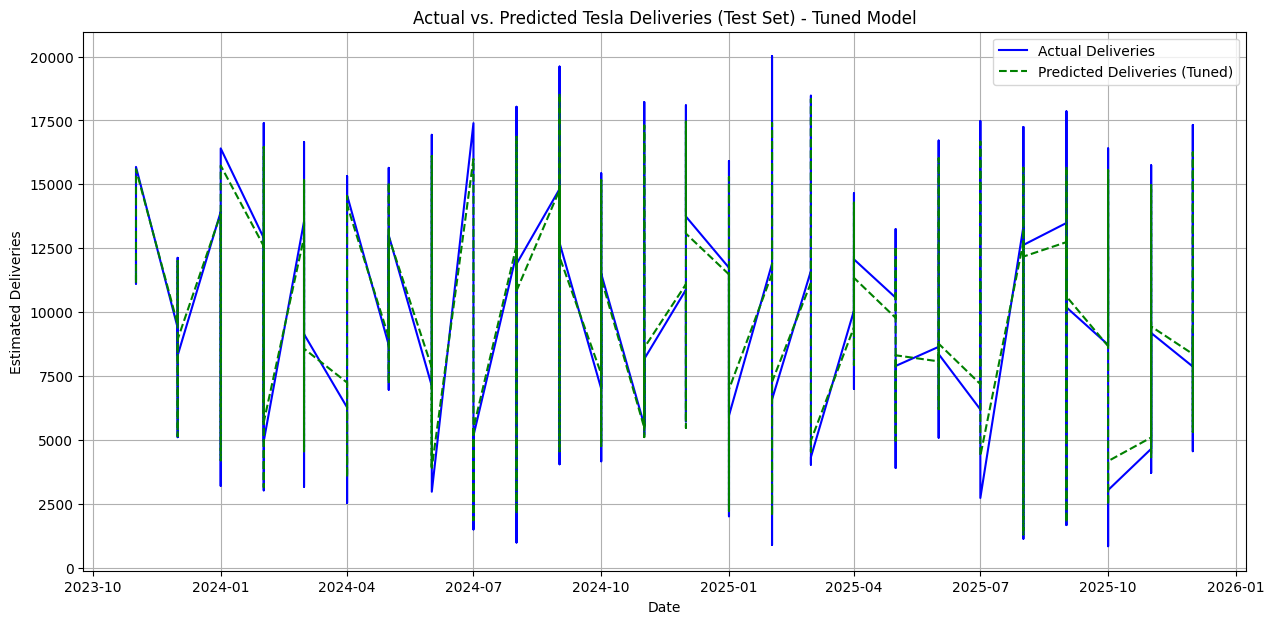

In [49]:
# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found:", best_params)

best_rf_model = grid_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"\nTuned Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned:.2f}")
print(f"R-squared (R2): {r2_tuned:.2f}")

print(f"\nInitial Model MAE: {mae:.2f}, Tuned Model MAE: {mae_tuned:.2f}")
print(f"Initial Model R2: {r2:.2f}, Tuned Model R2: {r2_tuned:.2f}")

# Visualize predictions vs actuals for the tuned model
plt.figure(figsize=(15, 7))
plt.plot(df_sorted['Date'].iloc[split_point:], y_test, label='Actual Deliveries', color='blue')
plt.plot(df_sorted['Date'].iloc[split_point:], y_pred_tuned, label='Predicted Deliveries (Tuned)', color='green', linestyle='--')
plt.title('Actual vs. Predicted Tesla Deliveries (Test Set) - Tuned Model')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

### Time Series Forecasting

Now, we'll use our best-tuned model to forecast future Tesla deliveries. This involves creating a future DataFrame with the same features as our training data and then predicting deliveries for those future periods.

In [50]:
from pandas.tseries.offsets import MonthEnd
import numpy as np

# Determine the last date in our original dataset
last_date = df_sorted['Date'].max()

future_dates = pd.date_range(start=last_date + MonthEnd(1), periods=12, freq='M')


future_df = pd.DataFrame({'Date': future_dates})
future_df['Year'] = future_df['Date'].dt.year
future_df['Month'] = future_df['Date'].dt.month
future_df['Quarter'] = future_df['Date'].dt.quarter


df_original_temp = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
unique_regions = df_original_temp['Region'].unique()
unique_models = df_original_temp['Model'].unique()
unique_source_types = df_original_temp['Source_Type'].unique()

forecast_dfs = []
for region in unique_regions:
    for model_type in unique_models:
        for source_type in unique_source_types:
            temp_df = future_df.copy()
            temp_df['Region'] = region
            temp_df['Model'] = model_type
            temp_df['Source_Type'] = source_type
            forecast_dfs.append(temp_df)

future_data = pd.concat(forecast_dfs, ignore_index=True)

future_data['Month_sin'] = np.sin(2 * np.pi * future_data['Month'] / 12)
future_data['Month_cos'] = np.cos(2 * np.pi * future_data['Month'] / 12)
future_data['Quarter_sin'] = np.sin(2 * np.pi * future_data['Quarter'] / 4)
future_data['Quarter_cos'] = np.cos(2 * np.pi * future_data['Quarter'] / 4)

# One-hot encode categorical features for future data (ensure consistent columns)
future_data = pd.get_dummies(future_data, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

missing_cols = set(X_train.columns) - set(future_data.columns)
for c in missing_cols:
    future_data[c] = 0


cols_to_keep = set(X_train.columns) | {'Date'}
extra_cols_to_drop_from_future_data = set(future_data.columns) - cols_to_keep
future_data.drop(columns=list(extra_cols_to_drop_from_future_data), inplace=True, errors='ignore')

cat_cols_for_grouping = [col for col in X_train.columns if 'Region_' in col or 'Model_' in col or 'Source_Type_' in col]
last_known_data = df_sorted.groupby(cat_cols_for_grouping).last()

future_data['Forecasted_Deliveries'] = np.nan # Initialize with NaN

# Iterate through each unique categorical combination to forecast
unique_cat_combinations = df_sorted[cat_cols_for_grouping].drop_duplicates()

for index, cat_values_series in unique_cat_combinations.iterrows():
    # Convert series to tuple of int for matching with last_known_data index
    cat_values_tuple = tuple(cat_values_series.astype(int))

    try:
        matching_last_known = last_known_data.loc[cat_values_tuple]
    except KeyError:
        continue

    mask_cat_combination = (future_data[cat_cols_for_grouping] == cat_values_series).all(axis=1)
    future_data_subset = future_data[mask_cat_combination].sort_values(by='Date').copy() # Ensure chronological order

    # Initialize lags for the first future period for this subset
    if not future_data_subset.empty:
        # For the first future month for this group, use the last known historical values
        future_data_subset.loc[future_data_subset.index[0], 'Deliveries_Lag_1'] = matching_last_known['Estimated_Deliveries']
        if 'Deliveries_Lag_2' in future_data_subset.columns:
            future_data_subset.loc[future_data_subset.index[0], 'Deliveries_Lag_2'] = matching_last_known['Deliveries_Lag_1']
        if 'Deliveries_Lag_3' in future_data_subset.columns:
            future_data_subset.loc[future_data_subset.index[0], 'Deliveries_Lag_3'] = matching_last_known['Deliveries_Lag_2']

    # Predict in a loop for this specific categorical combination
    for j in range(len(future_data_subset)):
        current_features = future_data_subset.iloc[j:j+1][X_train.columns] # Select only X_train columns for prediction

        # Ensure all columns in current_features are numeric (convert bool to int)
        for col in current_features.columns:
            if current_features[col].dtype == 'bool':
                current_features[col] = current_features[col].astype(int)

        pred = best_rf_model.predict(current_features)[0]
        future_data_subset.loc[future_data_subset.index[j], 'Forecasted_Deliveries'] = pred

        # Update the lags for the *next* time step in this specific group
        if j + 1 < len(future_data_subset):
            # The predicted value becomes the lag 1 for the next period
            future_data_subset.loc[future_data_subset.index[j+1], 'Deliveries_Lag_1'] = pred
            if 'Deliveries_Lag_2' in future_data_subset.columns:

                future_data_subset.loc[future_data_subset.index[j+1], 'Deliveries_Lag_2'] = future_data_subset.loc[future_data_subset.index[j], 'Deliveries_Lag_1']
            if 'Deliveries_Lag_3' in future_data_subset.columns:

                future_data_subset.loc[future_data_subset.index[j+1], 'Deliveries_Lag_3'] = future_data_subset.loc[future_data_subset.index[j], 'Deliveries_Lag_2']

    # Merge the forecasted values back to the main future_data DataFrame
    future_data.loc[future_data_subset.index, 'Forecasted_Deliveries'] = future_data_subset['Forecasted_Deliveries']



monthly_forecasts = future_data.groupby('Date')['Forecasted_Deliveries'].sum().reset_index()

display(monthly_forecasts.head())

/tmp/ipykernel_5725/1104890675.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + MonthEnd(1), periods=12, freq='M')


,Date,Forecasted_Deliveries
0,2025-12-31,0.0
1,2026-01-31,0.0
2,2026-02-28,0.0
3,2026-03-31,0.0
4,2026-04-30,0.0


### Visualize Forecasted Deliveries

Now, let's visualize the historical actual deliveries, the model's predictions on the test set, and our new future forecasts to get a complete picture.

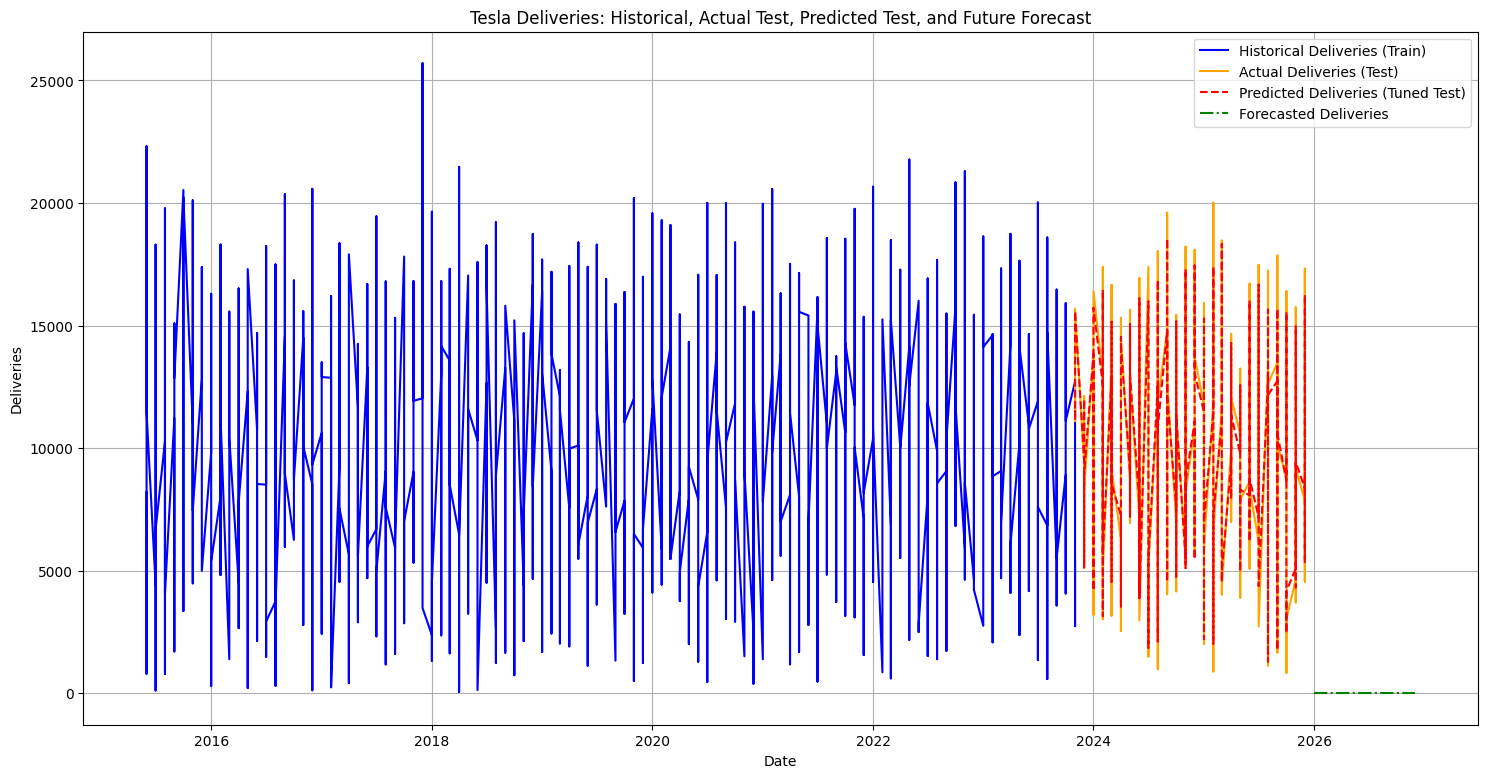

In [51]:
plt.figure(figsize=(18, 9))

# Plot historical data (training part)
plt.plot(df_sorted['Date'].iloc[:split_point], y_train, label='Historical Deliveries (Train)', color='blue')

# Plot actual test data
plt.plot(df_sorted['Date'].iloc[split_point:], y_test, label='Actual Deliveries (Test)', color='orange')

# Plot predicted test data from tuned model
plt.plot(df_sorted['Date'].iloc[split_point:], y_pred_tuned, label='Predicted Deliveries (Tuned Test)', color='red', linestyle='--')

plt.plot(monthly_forecasts['Date'], monthly_forecasts['Forecasted_Deliveries'], label='Forecasted Deliveries', color='green', linestyle='-.')

plt.title('Tesla Deliveries: Historical, Actual Test, Predicted Test, and Future Forecast')
plt.xlabel('Date')
plt.ylabel('Deliveries')
plt.legend()
plt.grid(True)
plt.show()